# 👩‍💻 Train an MLP for Handwritten Digit Classification

## 📋 Overview
In this lab, you will build and train a Multilayer Perceptron (MLP) neural network to classify handwritten digits using the MNIST dataset. This practical application of deep learning represents a fundamental computer vision task that's widely used in real-world applications like postal mail sorting, form-digitization, and document processing. By the end of this lab, you'll have created a complete machine learning pipeline from data loading to model evaluation.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Construct a custom MLP using PyTorch's neural network modules
- Implement a complete training and evaluation workflow for neural networks
- Visualize and interpret model performance metrics
- Apply optimization techniques to improve neural network performance

## 🚀 Starting Point
Required tools/setup:
   - Python 3.6+
   - PyTorch
   - torchvision
   - matplotlib
   - numpy

Access the starter code:

In [1]:
# Starter code
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns


# Set random seed for reproducibility
torch.manual_seed(42)

# TODO: Complete the lab implementation

## Task 1: Data Loading and Preprocessing
**Context:** Before training any machine learning model, we need properly formatted data. For image classification tasks like MNIST digit recognition, we need to load the images, normalize the pixel values, and organize them into batches for efficient training.

**Steps:**

1. Define a transformation pipeline to convert images to tensors and normalize the values

In [2]:
# TODO: Create a transform composition that converts images to tensors 
# and normalizes them with mean=0.5 and std=0.5
# Hint: Use transforms.Compose with ToTensor() and Normalize

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

2. Load the MNIST training and test datasets using torchvision's datasets module

In [3]:
# TODO: Load MNIST training and test data 
# Set appropriate parameters for:
# - data directory location
# - train/test split
# - downloading if needed
# - applying transforms
# Hint: Use datasets.MNIST

train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

3. Create data loaders for efficient batch processing during training

In [4]:
# TODO: Create DataLoader objects for training and testing
# Consider appropriate batch sizes and whether to shuffle the data
# Hint: Use torch.utils.data.DataLoader

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

4. Visualize sample images from the dataset to verify the loading process

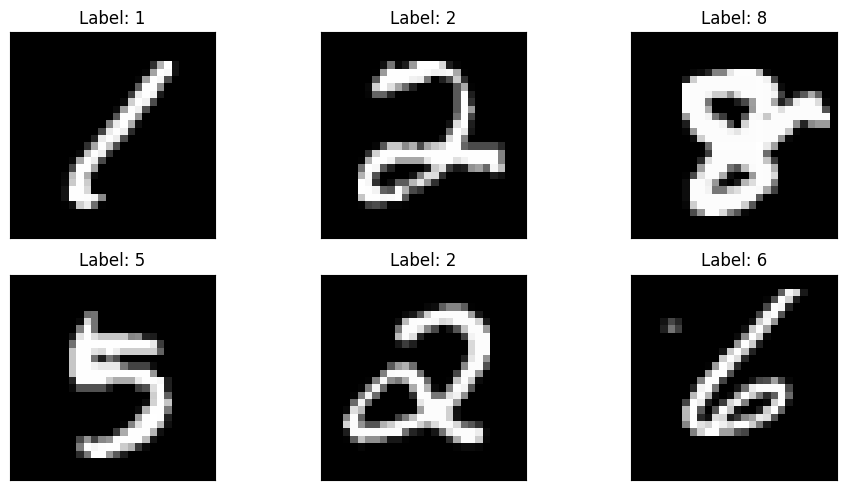

In [5]:
# TODO: Plot a grid of sample images with their labels
# Hint: Use matplotlib's subplot feature

plt.figure(figsize=(10, 5))
examples = iter(train_loader)
example_data, example_targets = next(examples)
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(example_data[i][0], cmap='gray')
    plt.title(f"Label: {example_targets[i]}")
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

**💡 Tip:** Normalizing image data to the range [-1, 1] or [0, 1] helps neural networks train more effectively by keeping inputs within a consistent range.

**⚙️ Test Your Work:**

- Print the shapes of your datasets and verify they match expected MNIST dimensions
- Display a few sample images to ensure they look like handwritten digits
- Confirm your DataLoader objects return properly formatted batches

## Task 2: Define a Custom MLP Model
**Context:** The architecture of a neural network determines its ability to learn patterns. For digit recognition, we'll create a Multilayer Perceptron that can learn to identify key features in handwritten digit images.

**Steps:**

1. Create a class that inherits from nn.Module to define our network architecture

In [6]:
# TODO: Define an MLP class that inherits from nn.Module
# Hint: Remember to implement both __init__ and forward methods

2. Initialize the network with appropriate layer dimensions

In [7]:
# TODO: In the __init__ method:
# - Create fully connected layers with appropriate input/output dimensions
# - Add activation functions like ReLU between layers
# - Consider the dimensionality of MNIST images (28x28 pixels)
# Hint: Use nn.Linear and nn.ReLU

3. Implement the forward method to define how data flows through the network

In [8]:
# TODO: In the forward method:
# - Reshape input images into flat vectors
# - Pass data through each layer and activation function
# - Return the final output
# Hint: Use the view method to reshape tensors

In [9]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x

4. Initialize an instance of your model

In [10]:
# TODO: Create an instance of your MLP class
model = MLP()

**💡 Tip:** When deciding layer sizes, consider the complexity of the task. For MNIST, a common architecture uses a hidden layer with 128 nodes followed by another with 64 nodes before the output layer of 10 nodes (one for each digit).

**⚙️ Test Your Work:**

- Print your model's structure to verify the architecture
- Pass a sample batch through the model to verify output dimensions
- Expected output shape should be [batch_size, 10] where 10 represents the possible digits (0-9)

## Task 3: Training Loop Implementation
**Context:** Training neural networks requires repeatedly showing examples to the model, calculating loss, and updating weights. This iterative process helps the model gradually learn patterns in the data.

**Steps:**

1. Define loss function and optimizer

In [11]:
# TODO: Define a loss function appropriate for classification
# Hint: CrossEntropyLoss works well for multi-class classification

# TODO: Create an optimizer to update model parameters
# Hint: Adam optimizer typically works well; consider a learning rate around 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

2. Implement the training loop

In [12]:
# TODO: Set up variables to track training progress
# - Number of epochs
# - Lists to store metrics for visualization

# TODO: Implement the training loop:
# - Iterate through epochs
# - For each batch:
#   * Zero gradients
#   * Forward pass
#   * Calculate loss
#   * Backward pass
#   * Update weights
# - Track and print metrics
# Hint: Use optimizer.zero_grad(), loss.backward(), and optimizer.step()

# Training Loop
epochs = 5
train_losses = []
train_counter = []
test_losses = []
test_counter = []
accuracy_list = []

def train(epoch):
    model.train()
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')
            train_losses.append(loss.item())
            train_counter.append((batch_idx * 64) + ((epoch - 1) * len(train_loader.dataset)))
    
    return running_loss / len(train_loader)

3. Track and store training metrics for later analysis

In [13]:
# TODO: Record loss values and accuracy for each epoch
# Hint: Store values in lists for later visualization

def test():
    model.eval()
    test_loss = 0
    correct = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            all_preds.extend(pred.view(-1).tolist())
            all_targets.extend(target.tolist())
    
    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')
    
    test_losses.append(test_loss)
    accuracy_list.append(accuracy)
    
    return test_loss, accuracy, all_preds, all_targets

**💡 Tip:** Print progress updates during training to monitor how your model is performing. Sudden spikes in loss may indicate issues with the learning rate or batch normalization.

**⚙️ Test Your Work:**

- Verify that loss decreases over epochs
- Check for any NaN values in loss (indicates numerical problems)
- Monitor training time to ensure the process is proceeding efficiently

## Task 4: Model Evaluation and Visualization
**Context:** After training, we need to evaluate our model on unseen data to understand its true performance. Visualizations help us interpret results and identify where the model succeeds or fails.

**Steps:**

1. Implement model evaluation on the test set

In [14]:
# TODO: Evaluate the trained model on test data:
# - Set model to evaluation mode
# - Iterate through test batches
# - Make predictions and compare with true labels
# - Calculate accuracy and other relevant metrics
# Hint: Use torch.no_grad() for efficient inference, model.eval()

# Task 4: Model Evaluation and Visualization
for epoch in range(1, epochs + 1):
    avg_loss = train(epoch)
    test_loss, accuracy, preds, targets = test()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.306995
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.689798
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.518994
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.304596
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.459589
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.461956
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.274198
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.270489
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.226629
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.264461

Test set: Average loss: 0.2057, Accuracy: 9353/10000 (93.53%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.273389
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.217030
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.386951
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.253178
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.406975
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.165830
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.200741
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.117263
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.22884

2. Visualize sample predictions to qualitatively assess model performance

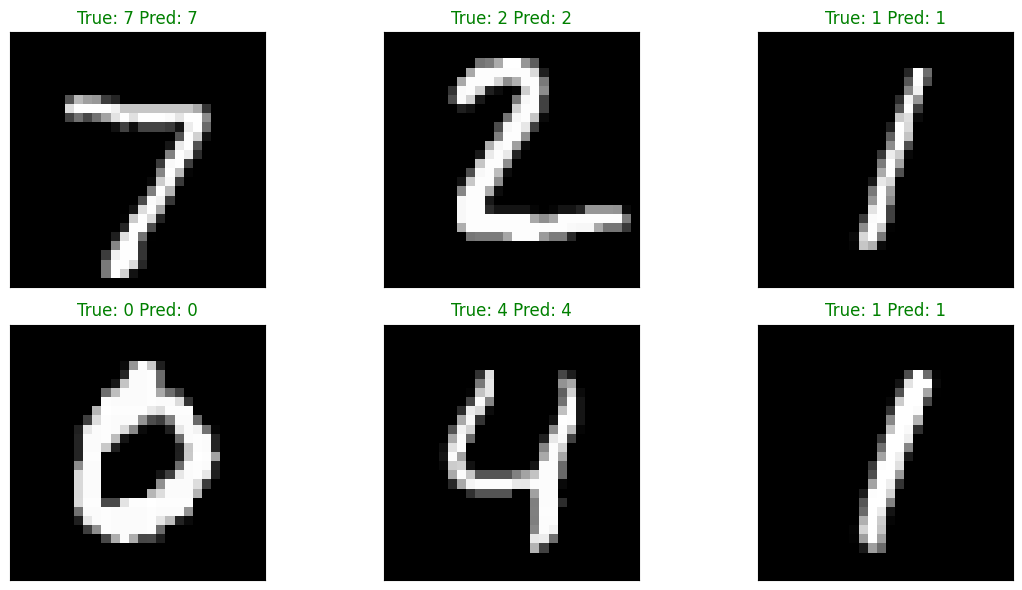

In [15]:
# TODO: Display a grid of test images alongside:
# - True labels
# - Predicted labels
# - Whether the prediction was correct (e.g., using color)
# Hint: Use matplotlib's subplots and imshow


# Visualize predictions
def visualize_predictions():
    model.eval()
    with torch.no_grad():
        data, target = next(iter(test_loader))
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True).view(-1)
        
        fig = plt.figure(figsize=(12, 6))
        for idx in range(6):
            ax = fig.add_subplot(2, 3, idx+1)
            ax.imshow(data[idx][0], cmap='gray')
            color = 'green' if pred[idx] == target[idx] else 'red'
            ax.set_title(f"True: {target[idx]} Pred: {pred[idx]}", color=color)
            ax.set_xticks([])
            ax.set_yticks([])
        plt.tight_layout()
        plt.show()

visualize_predictions()

3. Plot training metrics to visualize learning progress

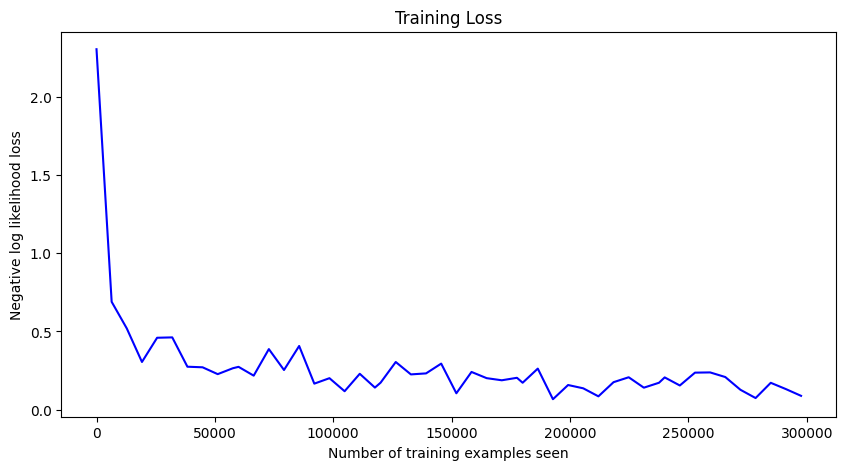

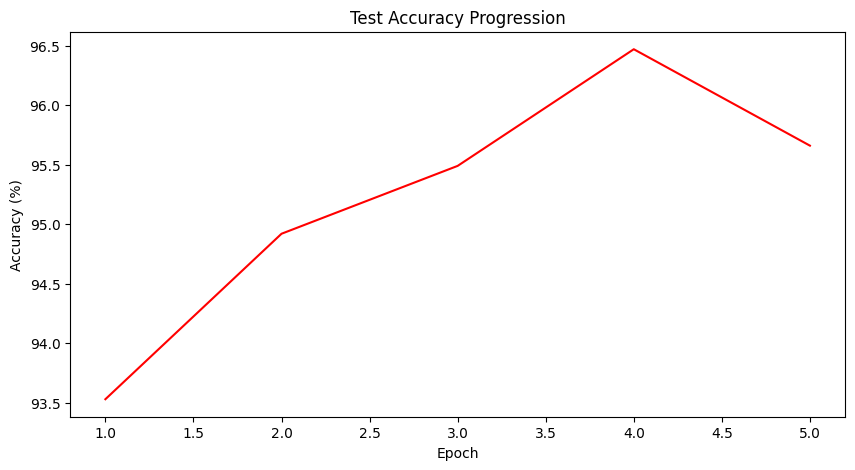

In [16]:
# TODO: Create plots showing:
# - Training loss over epochs
# - Accuracy over epochs
# Hint: Use matplotlib's plot function
# Plot training and testing loss

# Plot training and testing loss
plt.figure(figsize=(10, 5))
plt.plot(train_counter, train_losses, color='blue')
plt.xlabel('Number of training examples seen')
plt.ylabel('Negative log likelihood loss')
plt.title('Training Loss')
plt.show()

# Plot accuracy progression
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), accuracy_list, color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Progression')
plt.show()

4. Analyze model performance on different digit classes


Test set: Average loss: 0.1359, Accuracy: 9566/10000 (95.66%)



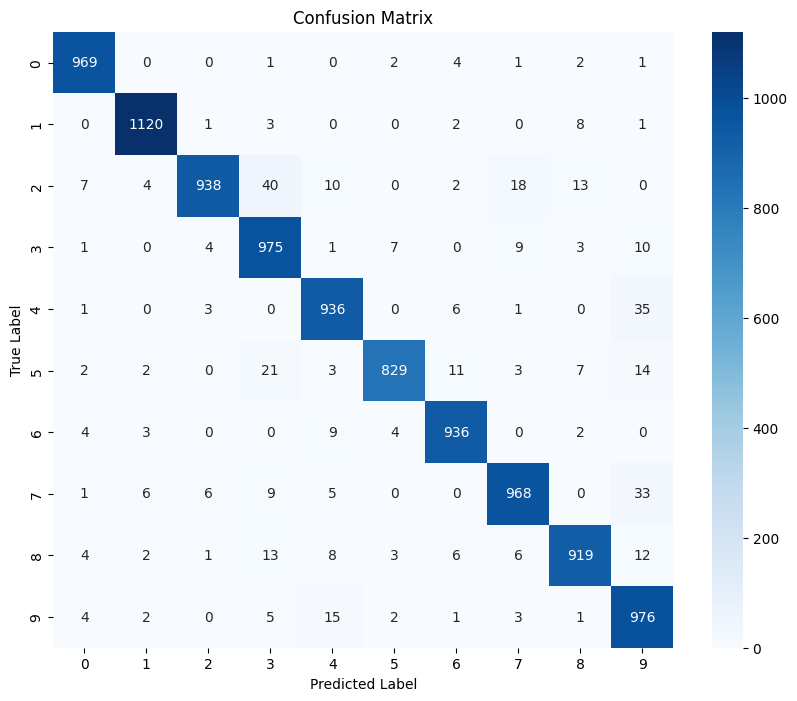

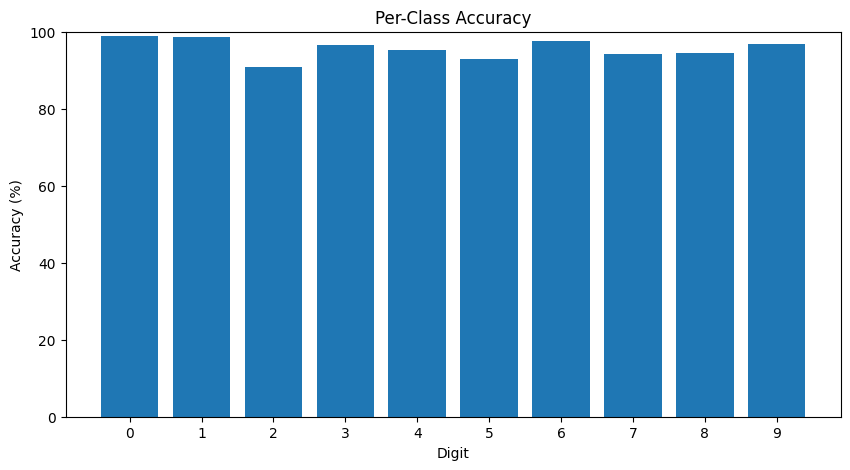

In [17]:
# TODO: Calculate and visualize per-class accuracy
# - Create a confusion matrix
# - Plot per-digit accuracy
# Hint: Use sklearn's confusion_matrix and a heatmap visualization
# Visualize predictions
# Generate confusion matrix

def plot_confusion_matrix(preds, targets):
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Per-class accuracy
    per_class_accuracy = 100 * np.diag(cm) / np.sum(cm, axis=1)
    plt.figure(figsize=(10, 5))
    plt.bar(range(10), per_class_accuracy)
    plt.xlabel('Digit')
    plt.ylabel('Accuracy (%)')
    plt.title('Per-Class Accuracy')
    plt.xticks(range(10))
    plt.ylim(0, 100)
    plt.show()

_, _, all_preds, all_targets = test()
plot_confusion_matrix(all_preds, all_targets)

**💡 Tip:** A confusion matrix is a powerful tool for identifying which digits are commonly misclassified as others, helping you understand the model's strengths and weaknesses.

**⚙️ Test Your Work:**

- Verify overall accuracy is reasonable (>95% is achievable with a basic MLP on MNIST)
- Confirm per-class metrics sum correctly
- Check that visualizations clearly show model performance trends

## ✅ Success Checklist
- Dataset successfully loaded and preprocessed with normalization
- MLP model architecture implemented with appropriate layers and activations
- Training loop executes without errors and loss decreases over time
- Model achieves at least 95% accuracy on the test dataset
- Training metrics are properly visualized
- Sample predictions are displayed with correct and incorrect results identified
- Per-class performance analysis completed

## 🔍 Common Issues & Solutions
**Problem:** Model accuracy is too low
**Solution:** Check normalizing values, increase model capacity (add more neurons or layers), train for more epochs, or try a different optimizer.

**Problem:** Loss isn't decreasing during training
**Solution:** Verify learning rate (may be too high or too low), check for proper data normalization, ensure proper model initialization.

**Problem:** Memory errors during training
**Solution:** Reduce batch size, simplify model architecture, or use CPU instead of GPU if memory is limited.

**Problem:** Overfitting (high training accuracy, low test accuracy)
**Solution:** Add dropout layers, implement early stopping, or use a simpler model architecture.

## 🔑 Key Points
- Data preprocessing is critical for neural network performance
- MLP architecture design involves trade-offs between model complexity and generalization
- Monitoring training metrics helps diagnose issues early
- Visualization is essential for understanding model behavior and performance
- MNIST is an excellent starting dataset, but real-world image tasks often require more complex architectures like CNNs

## 💻 Reference Solution

<details>    
<summary><strong>Click HERE to see a reference solution</strong></summary>    

```python
# Task 1: Data Loading and Preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

# Visualize some training examples
plt.figure(figsize=(10, 5))
examples = iter(train_loader)
example_data, example_targets = next(examples)
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(example_data[i][0], cmap='gray')
    plt.title(f"Label: {example_targets[i]}")
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

# Task 2: Define MLP Model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x

# Initialize the model, loss function, and optimizer
model = MLP()

# Task 3: Training Loop Implementation
# Define loss function and optimizer    
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
    
# Training Loop
epochs = 5
train_losses = []
train_counter = []
test_losses = []
test_counter = []
accuracy_list = []

def train(epoch):
    model.train()
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')
            train_losses.append(loss.item())
            train_counter.append((batch_idx * 64) + ((epoch - 1) * len(train_loader.dataset)))
    
    return running_loss / len(train_loader)

def test():
    model.eval()
    test_loss = 0
    correct = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            all_preds.extend(pred.view(-1).tolist())
            all_targets.extend(target.tolist())
    
    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')
    
    test_losses.append(test_loss)
    accuracy_list.append(accuracy)
    
    return test_loss, accuracy, all_preds, all_targets

# Task 4: Model Evaluation and Visualization
for epoch in range(1, epochs + 1):
    avg_loss = train(epoch)
    test_loss, accuracy, preds, targets = test()
    
# Visualize predictions
def visualize_predictions():
    model.eval()
    with torch.no_grad():
        data, target = next(iter(test_loader))
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True).view(-1)
        
        fig = plt.figure(figsize=(12, 6))
        for idx in range(6):
            ax = fig.add_subplot(2, 3, idx+1)
            ax.imshow(data[idx][0], cmap='gray')
            color = 'green' if pred[idx] == target[idx] else 'red'
            ax.set_title(f"True: {target[idx]} Pred: {pred[idx]}", color=color)
            ax.set_xticks([])
            ax.set_yticks([])
        plt.tight_layout()
        plt.show()

visualize_predictions()

# Plot training and testing loss
plt.figure(figsize=(10, 5))
plt.plot(train_counter, train_losses, color='blue')
plt.xlabel('Number of training examples seen')
plt.ylabel('Negative log likelihood loss')
plt.title('Training Loss')
plt.show()

# Plot accuracy progression
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), accuracy_list, color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Progression')
plt.show()


# Generate confusion matrix
def plot_confusion_matrix(preds, targets):
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Per-class accuracy
    per_class_accuracy = 100 * np.diag(cm) / np.sum(cm, axis=1)
    plt.figure(figsize=(10, 5))
    plt.bar(range(10), per_class_accuracy)
    plt.xlabel('Digit')
    plt.ylabel('Accuracy (%)')
    plt.title('Per-Class Accuracy')
    plt.xticks(range(10))
    plt.ylim(0, 100)
    plt.show()

_, _, all_preds, all_targets = test()
plot_confusion_matrix(all_preds, all_targets)
```